<a href="https://colab.research.google.com/github/ryrynbob/ust-deep-learning-2026/blob/main/Week10_RyanNguyen_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vision Transformer (ViT) — Colab notebook for a 10-minute presentation

This notebook is designed to help you produce the three things your Week 10 presentation needs:

1. **Training curves**
2. **Prediction/output screenshots**
3. **Latent embedding visualization**

It uses the Keras ViT example as the base implementation and adds:
- a **faster Colab-friendly workflow**
- one **clean experiment** (`patch_size=6` vs `patch_size=8`)
- code to **save presentation screenshots** automatically

Recommended runtime: **GPU** in Google Colab.

**Assignment reminder:** your instructor requires 3 slides: problem/motivation, architecture/design choices, and your own run/results/surprises. fileciteturn3file0L58-L66


## Step 0 — Presentation game plan

Use this notebook in this order:

- Run the **setup and data** cells
- Run the **baseline model** (`patch_size = 6`)
- Save screenshots of:
  - training curves
  - prediction examples
  - latent embedding
- Run the **experiment model** (`patch_size = 8`)
- Compare results and use that comparison for Slide 3

Your talking point can be:
> “I tested whether larger patches would make training faster, but I expected some loss of fine-grained detail on CIFAR-100.”


In [1]:

# =========================================
# 1. Setup
# =========================================
!pip -q install -U keras tensorflow scikit-learn matplotlib

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

from keras import layers
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUTPUT_DIR = "/content/vit_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# FAST_MODE is tuned for a presentation/demo workflow.
# Change to False if you want a larger run.
FAST_MODE = True


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 300.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 23.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 7.34.0 which is incompatible.
google-cloud-bigquery-connection 1.20.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.34.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you

In [2]:

# =========================================
# 2. Load CIFAR-100 data
# =========================================
num_classes = 100
input_shape = (32, 32, 3)

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data()

print("Original train:", x_train.shape, y_train.shape)
print("Original test :", x_test.shape, y_test.shape)

if FAST_MODE:
    train_n = 15000
    test_n = 3000
else:
    train_n = len(x_train)
    test_n = len(x_test)

x_train = x_train[:train_n]
y_train = y_train[:train_n]
x_test = x_test[:test_n]
y_test = y_test[:test_n]

print("Working train:", x_train.shape, y_train.shape)
print("Working test :", x_test.shape, y_test.shape)


169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Original train: (50000, 32, 32, 3) (50000, 1)
Original test : (10000, 32, 32, 3) (10000, 1)
Working train: (15000, 32, 32, 3) (15000, 1)
Working test : (3000, 32, 32, 3) (3000, 1)


## Step 1 — Choose a presentation-friendly configuration

The original Keras example uses 10 epochs as a test value and notes that much stronger performance comes with longer training and large-scale pretraining. citeturn269468search0turn269468search1

For a class presentation, the goal is not SOTA accuracy. The goal is to:
- understand the architecture,
- produce readable outputs,
- and show one thoughtful experiment.


In [3]:

# =========================================
# 3. Shared utilities
# =========================================
learning_rate = 1e-3
weight_decay = 1e-4
batch_size = 128 if FAST_MODE else 256
num_epochs = 5 if FAST_MODE else 10
image_size = 72
projection_dim = 64
num_heads = 4
transformer_layers = 6 if FAST_MODE else 8
transformer_units = [projection_dim * 2, projection_dim]
mlp_head_units = [512, 256] if FAST_MODE else [2048, 1024]

class_names = [
    "apple","aquarium_fish","baby","bear","beaver","bed","bee","beetle","bicycle","bottle",
    "bowl","boy","bridge","bus","butterfly","camel","can","castle","caterpillar","cattle",
    "chair","chimpanzee","clock","cloud","cockroach","couch","crab","crocodile","cup","dinosaur",
    "dolphin","elephant","flatfish","forest","fox","girl","hamster","house","kangaroo","keyboard",
    "lamp","lawn_mower","leopard","lion","lizard","lobster","man","maple_tree","motorcycle","mountain",
    "mouse","mushroom","oak_tree","orange","orchid","otter","palm_tree","pear","pickup_truck","pine_tree",
    "plain","plate","poppy","porcupine","possum","rabbit","raccoon","ray","road","rocket",
    "rose","sea","seal","shark","shrew","skunk","skyscraper","snail","snake","spider",
    "squirrel","streetcar","sunflower","sweet_pepper","table","tank","telephone","television","tiger","tractor",
    "train","trout","tulip","turtle","wardrobe","whale","willow_tree","wolf","woman","worm"
]

def make_data_augmentation(image_size):
    aug = keras.Sequential(
        [
            layers.Normalization(),
            layers.Resizing(image_size, image_size),
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.02),
            layers.RandomZoom(height_factor=0.2, width_factor=0.2),
        ],
        name="data_augmentation",
    )
    aug.layers[0].adapt(x_train)
    return aug

def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

def create_vit_classifier(patch_size=6):
    num_patches = (image_size // patch_size) ** 2
    data_augmentation = make_data_augmentation(image_size)

    inputs = keras.Input(shape=input_shape)
    augmented = data_augmentation(inputs)
    patches = Patches(patch_size)(augmented)
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        x2 = layers.Add()([attention_output, encoded_patches])

        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        encoded_patches = layers.Add()([x3, x2])

    representation = layers.LayerNormalization(epsilon=1e-6, name="final_layernorm")(encoded_patches)
    representation = layers.Flatten(name="flatten_representation")(representation)
    representation = layers.Dropout(0.5)(representation)

    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)
    logits = layers.Dense(num_classes, name="logits")(features)

    model = keras.Model(inputs=inputs, outputs=logits)
    return model

def compile_model(model):
    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate,
        weight_decay=weight_decay
    )

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            keras.metrics.SparseTopKCategoricalAccuracy(5, name="top_5_accuracy"),
        ],
    )
    return model


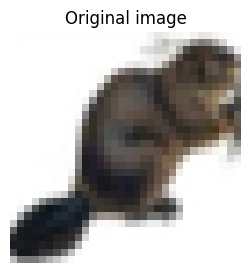

Image size: 72 x 72
Patch size: 6 x 6
Patches per image: 144
Elements per patch: 108


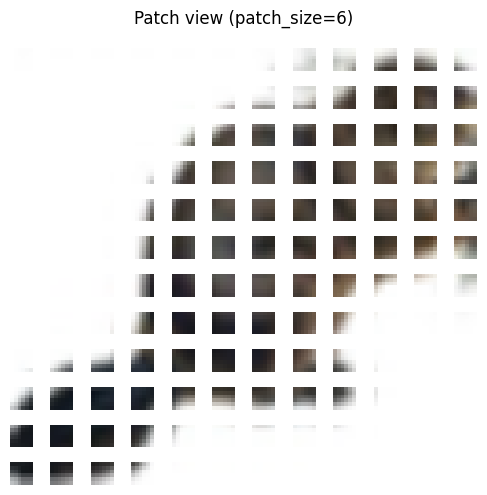

In [4]:

# =========================================
# 4. Visualize patches (great for Slide 2)
# =========================================
def show_patches(sample_idx=None, patch_size=6):
    if sample_idx is None:
        sample_idx = np.random.randint(0, len(x_train))

    image = x_train[sample_idx]
    plt.figure(figsize=(3, 3))
    plt.imshow(image.astype("uint8"))
    plt.title("Original image")
    plt.axis("off")
    plt.show()

    resized = tf.image.resize(tf.convert_to_tensor([image]), size=(image_size, image_size))
    patches = Patches(patch_size)(resized)
    print(f"Image size: {image_size} x {image_size}")
    print(f"Patch size: {patch_size} x {patch_size}")
    print(f"Patches per image: {patches.shape[1]}")
    print(f"Elements per patch: {patches.shape[-1]}")

    n = int(np.sqrt(patches.shape[1]))
    plt.figure(figsize=(5, 5))
    for i, patch in enumerate(patches[0]):
        ax = plt.subplot(n, n, i + 1)
        patch_img = tf.reshape(patch, (patch_size, patch_size, 3))
        plt.imshow(tf.cast(patch_img, tf.uint8))
        plt.axis("off")
    plt.suptitle(f"Patch view (patch_size={patch_size})")
    plt.tight_layout()
    plt.show()

show_patches(patch_size=6)


## Step 2 — Run the baseline model

This is the run you will use for most of Slide 3.

Your safest experiment is:
- **Baseline:** `patch_size = 6`
- **Experiment:** `patch_size = 8`

Why this is a good experiment:
- patch size directly changes token count,
- it is easy to explain,
- and it affects both computation and fine-grained image detail.

The Keras example also explicitly notes patch size as one of the architecture choices that affects quality. citeturn269468search0turn269468search1


In [5]:

# =========================================
# 5. Train / evaluate helper
# =========================================
def run_experiment(patch_size=6, model_tag="baseline"):
    model = create_vit_classifier(patch_size=patch_size)
    model = compile_model(model)

    checkpoint_path = os.path.join(OUTPUT_DIR, f"{model_tag}_best.weights.h5")

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            checkpoint_path,
            monitor="val_accuracy",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=2,
            restore_best_weights=True,
            verbose=1,
        ),
    ]

    history = model.fit(
        x_train,
        y_train,
        batch_size=batch_size,
        epochs=num_epochs,
        validation_split=0.1,
        callbacks=callbacks,
        verbose=1,
    )

    if os.path.exists(checkpoint_path):
        model.load_weights(checkpoint_path)

    results = model.evaluate(x_test, y_test, verbose=0)
    metrics = dict(zip(model.metrics_names, results))
    print(f"\n[{model_tag}] Test metrics:")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    return model, history, metrics

baseline_model, baseline_history, baseline_metrics = run_experiment(
    patch_size=6,
    model_tag="baseline_patch6"
)


Epoch 1/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.0112 - loss: 5.1086 - top_5_accuracy: 0.0537
Epoch 1: val_accuracy improved from None to 0.01267, saving model to /content/vit_outputs/baseline_patch6_best.weights.h5

Epoch 1: finished saving model to /content/vit_outputs/baseline_patch6_best.weights.h5
106/106 ━━━━━━━━━━━━━━━━━━━━ 906s 8s/step - accuracy: 0.0104 - loss: 4.7421 - top_5_accuracy: 0.0540 - val_accuracy: 0.0127 - val_loss: 4.5809 - val_top_5_accuracy: 0.0760
Epoch 2/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.0109 - loss: 4.6028 - top_5_accuracy: 0.0563
Epoch 2: val_accuracy did not improve from 0.01267
106/106 ━━━━━━━━━━━━━━━━━━━━ 868s 8s/step - accuracy: 0.0104 - loss: 4.6033 - top_5_accuracy: 0.0550 - val_accuracy: 0.0107 - val_loss: 4.6065 - val_top_5_accuracy: 0.0460
Epoch 3/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.0115 - loss: 4.6043 - top_5_accuracy: 0.0521
Epoch 3: val_accuracy did not improve from 0.01267
106/106 ━━━━━━━━━

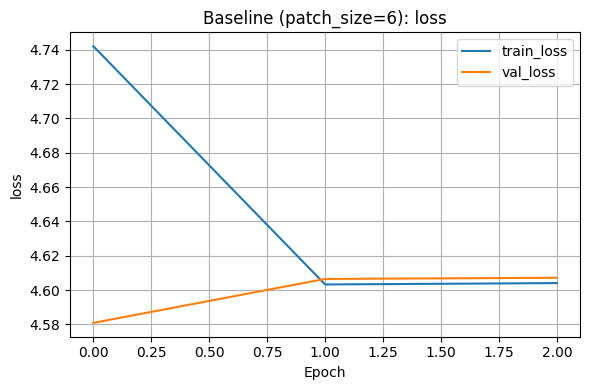

Saved: /content/vit_outputs/baseline_training_curves_loss.png


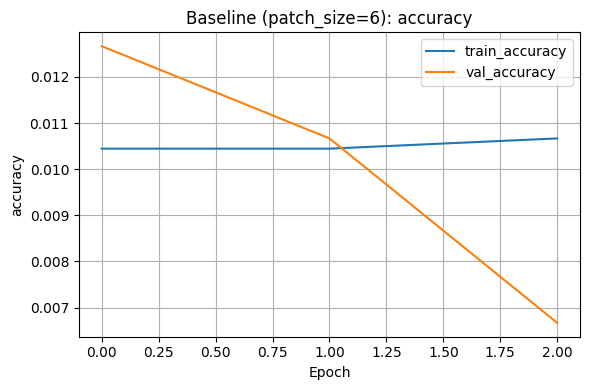

Saved: /content/vit_outputs/baseline_training_curves_accuracy.png


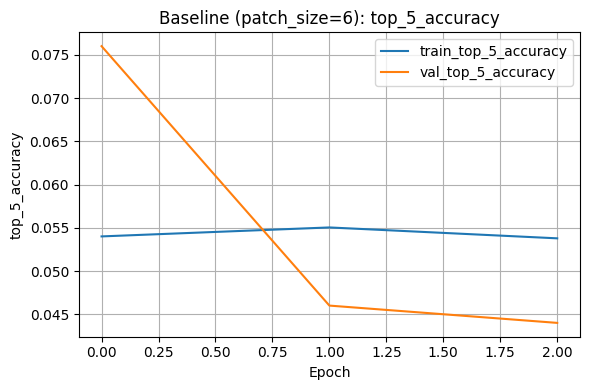

Saved: /content/vit_outputs/baseline_training_curves_top_5_accuracy.png


In [6]:

# =========================================
# 6. Save training curves for Slide 3
# =========================================
def plot_history(history, title_prefix="Baseline", save_prefix="baseline"):
    for metric in ["loss", "accuracy", "top_5_accuracy"]:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history[metric], label=f"train_{metric}")
        plt.plot(history.history[f"val_{metric}"], label=f"val_{metric}")
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.title(f"{title_prefix}: {metric}")
        plt.legend()
        plt.grid(True)
        out_path = os.path.join(OUTPUT_DIR, f"{save_prefix}_{metric}.png")
        plt.tight_layout()
        plt.savefig(out_path, dpi=200)
        plt.show()
        print("Saved:", out_path)

plot_history(
    baseline_history,
    title_prefix="Baseline (patch_size=6)",
    save_prefix="baseline_training_curves"
)


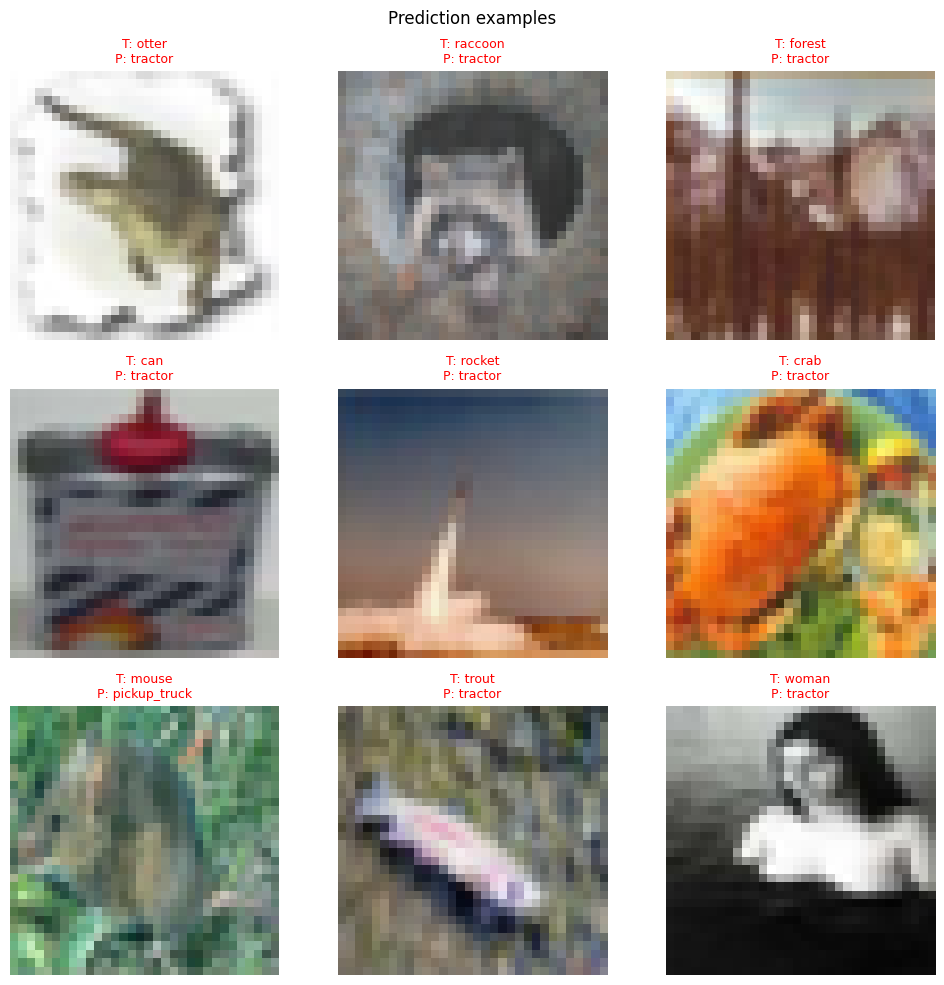

Saved: /content/vit_outputs/baseline_prediction_examples.png


In [7]:

# =========================================
# 7. Save prediction examples for Slide 3
# =========================================
def show_predictions(model, num_images=9, save_name="baseline_prediction_examples.png"):
    idx = np.random.choice(len(x_test), size=num_images, replace=False)
    images = x_test[idx]
    true_labels = y_test[idx].flatten()

    logits = model.predict(images, verbose=0)
    pred_labels = np.argmax(logits, axis=1)

    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].astype("uint8"))
        correct = pred_labels[i] == true_labels[i]
        plt.title(
            f"T: {class_names[true_labels[i]]}\nP: {class_names[pred_labels[i]]}",
            color=("green" if correct else "red"),
            fontsize=9
        )
        plt.axis("off")

    plt.suptitle("Prediction examples")
    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, save_name)
    plt.savefig(out_path, dpi=200)
    plt.show()
    print("Saved:", out_path)

show_predictions(baseline_model)


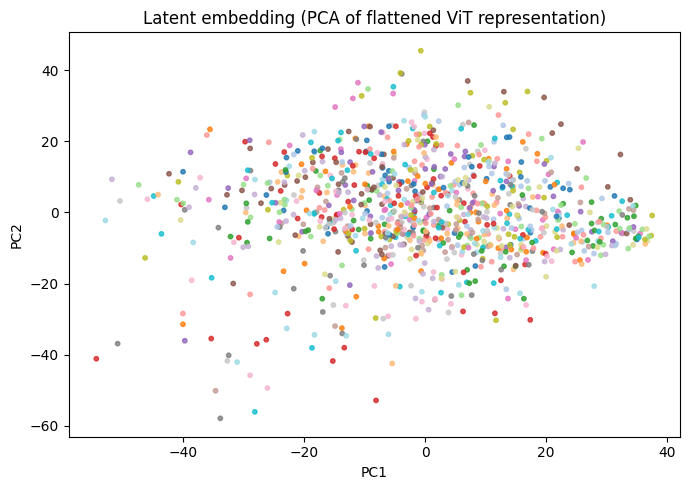

Saved: /content/vit_outputs/baseline_latent_embedding.png


In [8]:

# =========================================
# 8. Save latent embedding for Slide 3
# =========================================
def extract_features(model, x, batch_size=256):
    feature_model = keras.Model(
        inputs=model.input,
        outputs=model.get_layer("flatten_representation").output
    )
    features = feature_model.predict(x, batch_size=batch_size, verbose=0)
    return features

def plot_latent_embedding(model, x, y, sample_n=1000, save_name="baseline_latent_embedding.png"):
    sample_n = min(sample_n, len(x))
    idx = np.random.choice(len(x), size=sample_n, replace=False)
    x_sample = x[idx]
    y_sample = y[idx].flatten()

    features = extract_features(model, x_sample)
    pca = PCA(n_components=2, random_state=SEED)
    emb_2d = pca.fit_transform(features)

    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(
        emb_2d[:, 0],
        emb_2d[:, 1],
        c=y_sample,
        cmap="tab20",
        s=10,
        alpha=0.8
    )
    plt.title("Latent embedding (PCA of flattened ViT representation)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    out_path = os.path.join(OUTPUT_DIR, save_name)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()
    print("Saved:", out_path)

plot_latent_embedding(baseline_model, x_test, y_test)


## Step 3 — Run one experiment

For your presentation, this is enough:
- baseline: `patch_size = 6`
- experiment: `patch_size = 8`

What you can say:
> “I increased patch size so the model processes fewer tokens, which should reduce compute, but it may also throw away useful fine detail in small CIFAR-100 images.”

That is a strong, defensible experiment explanation.


Epoch 1/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.0140 - loss: 5.0557 - top_5_accuracy: 0.0558
Epoch 1: val_accuracy improved from None to 0.01600, saving model to /content/vit_outputs/experiment_patch8_best.weights.h5

Epoch 1: finished saving model to /content/vit_outputs/experiment_patch8_best.weights.h5
106/106 ━━━━━━━━━━━━━━━━━━━━ 426s 4s/step - accuracy: 0.0136 - loss: 4.7272 - top_5_accuracy: 0.0586 - val_accuracy: 0.0160 - val_loss: 4.5375 - val_top_5_accuracy: 0.0927
Epoch 2/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0147 - loss: 4.5742 - top_5_accuracy: 0.0709
Epoch 2: val_accuracy improved from 0.01600 to 0.02467, saving model to /content/vit_outputs/experiment_patch8_best.weights.h5

Epoch 2: finished saving model to /content/vit_outputs/experiment_patch8_best.weights.h5
106/106 ━━━━━━━━━━━━━━━━━━━━ 380s 4s/step - accuracy: 0.0161 - loss: 4.5601 - top_5_accuracy: 0.0770 - val_accuracy: 0.0247 - val_loss: 4.4617 - val_top_5_accuracy: 0.1293
Epoch 3

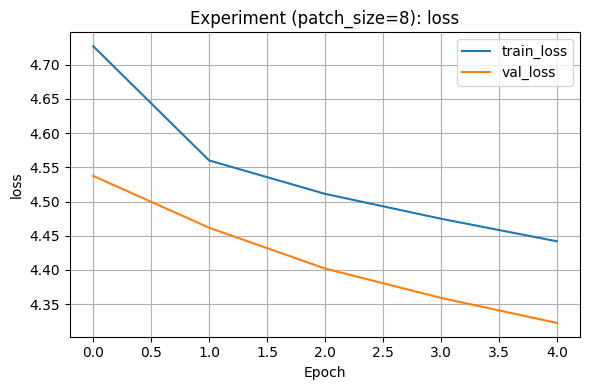

Saved: /content/vit_outputs/experiment_training_curves_loss.png


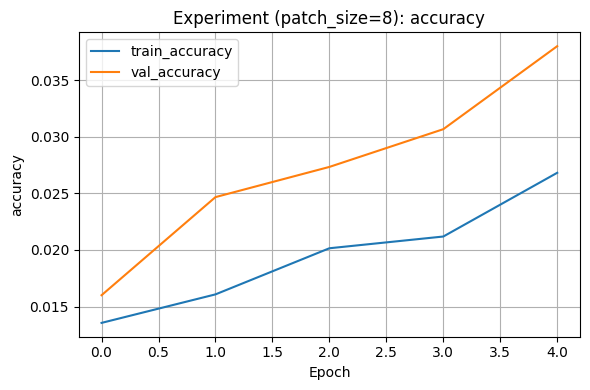

Saved: /content/vit_outputs/experiment_training_curves_accuracy.png


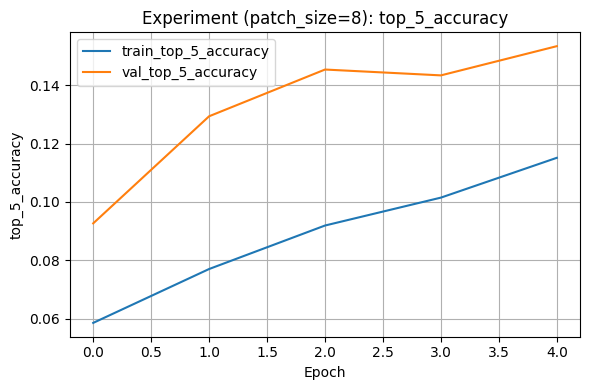

Saved: /content/vit_outputs/experiment_training_curves_top_5_accuracy.png


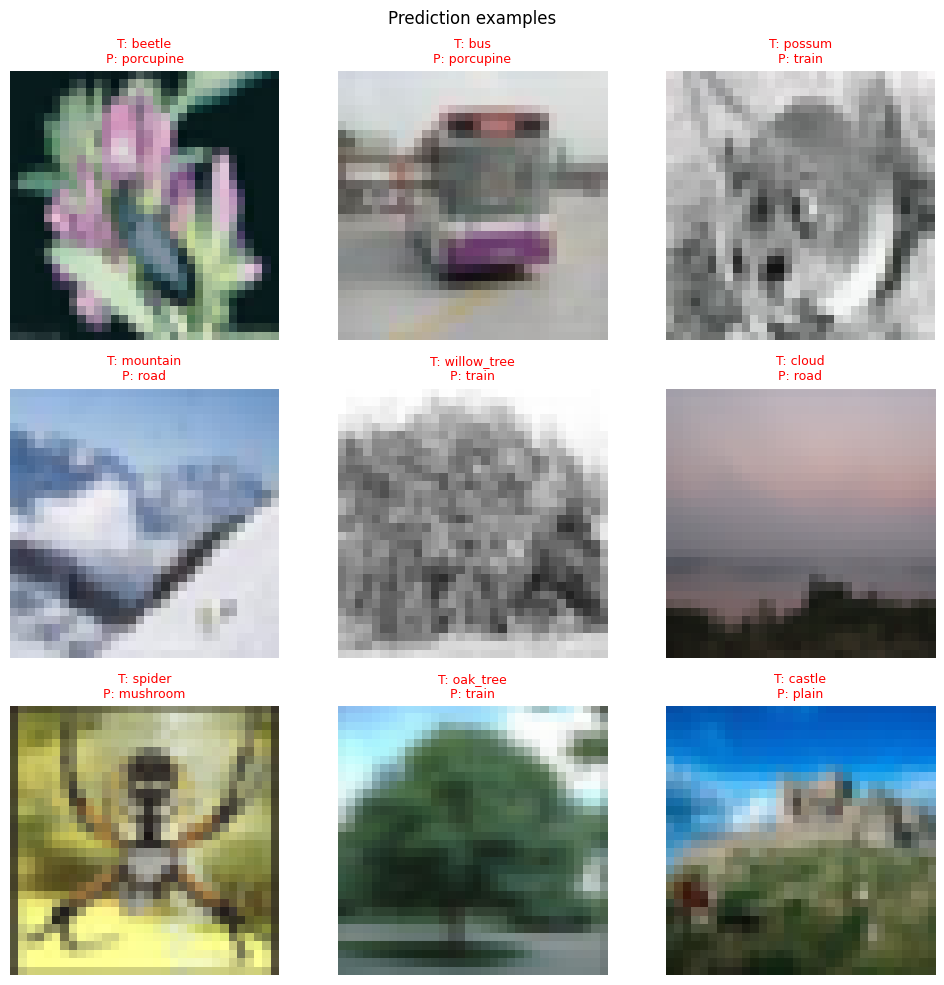

Saved: /content/vit_outputs/experiment_prediction_examples.png


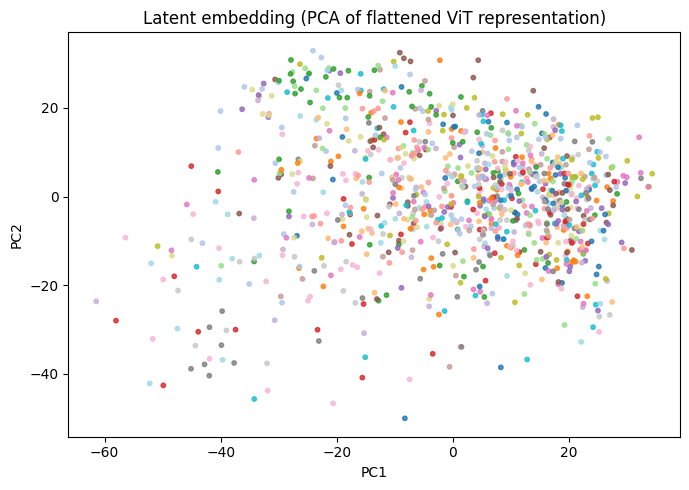

Saved: /content/vit_outputs/experiment_latent_embedding.png


In [9]:

# =========================================
# 9. Experiment: larger patches
# =========================================
experiment_model, experiment_history, experiment_metrics = run_experiment(
    patch_size=8,
    model_tag="experiment_patch8"
)

plot_history(
    experiment_history,
    title_prefix="Experiment (patch_size=8)",
    save_prefix="experiment_training_curves"
)
show_predictions(experiment_model, save_name="experiment_prediction_examples.png")
plot_latent_embedding(experiment_model, x_test, y_test, save_name="experiment_latent_embedding.png")


In [10]:

# =========================================
# 10. Compare baseline vs experiment
# =========================================
comparison = {
    "baseline_patch6": baseline_metrics,
    "experiment_patch8": experiment_metrics,
}
comparison


{'baseline_patch6': {'loss': 4.5872087478637695,
  'compile_metrics': 0.016333334147930145},
 'experiment_patch8': {'loss': 4.334944248199463,
  'compile_metrics': 0.03733333200216293}}

## Step 4 — What to put on Slide 3

Use your actual screenshot files from `/content/vit_outputs/` and say:

### Results
- “My baseline ViT learned slowly but did improve over epochs.”
- “Top-5 accuracy was much better than top-1 accuracy, which makes sense because CIFAR-100 has many small, similar classes.”
- “The latent embedding shows some class structure, but the clusters are still mixed.”

### My experiment
- “I changed patch size from 6 to 8 because patch size is a core ViT design choice.”
- “Larger patches reduce token count, so they can help speed, but they may remove fine detail.”

### Something unexpected
Choose the one that matches your run:
- “Accuracy stayed lower than I expected.”
- “Training was slower than a small CNN.”
- “The latent embedding looked noisier than I thought.”
- “The change in patch size affected speed more than accuracy.”

The Keras example itself notes that ViT performance on CIFAR-100 is not especially competitive when trained from scratch and improves much more with longer training and large-scale pretraining. citeturn269468search0turn269468search1


## Step 5 — Your exact 10-minute presentation split

### Slide 1 — Problem & motivation (about 3 minutes)
- ViT solves image classification.
- Simpler models struggle with long-range/global relationships.
- Real-world use case: medical image classification.

### Slide 2 — Architecture & design choices (about 3.5 minutes)
- Show your hand-drawn pipeline.
- Emphasize:
  1. patches + positional embeddings
  2. self-attention across patches
- Explain sparse categorical crossentropy from logits.

### Slide 3 — Your own run (about 3.5 minutes)
- Show training curves.
- Show prediction examples.
- Show latent embedding.
- Explain your patch-size experiment.
- End with one honest surprise.

That exactly matches the 3-slide assignment structure in your Week 10 PDF. fileciteturn3file0L58-L66
